# SAR2 · Text to Numbers: Tokens, Lexicons and Sentiment Scores

*Sentiment & Alternative Data track*

Models need numbers, not sentences. This notebook turns financial headlines into sentiment scores with the simplest method that works: counting positive and negative words. Along the way it shows where that method fails and why.

## 1. Motivation

A news feed delivers thousands of headlines a day. No person can read them all, but a program can, if it can turn "Meridian Bank sets aside more for bad loans as defaults climb" into something like −0.8. Every text-based strategy, from news sentiment to earnings-call analysis, starts with this step. The simplest approach, a word list, is still widely used in finance research because it is transparent: you can see exactly why a headline got its score.

## 2. Intuition

Read a headline the way a hurried trader skims it: look for words that usually mean good news ("beats", "surge", "upgrade") or bad news ("misses", "recall", "lawsuit"). Count them. More good words than bad means positive.

Three things make this harder than it sounds:

1. **Words mean different things in finance.** In everyday English "liability" or "tax" sound negative, while "crude" and "vice" sound bad for unrelated reasons. A general-purpose word list misreads financial text. This is why researchers built finance-specific lists (the best known is the Loughran–McDonald dictionary).
2. **Negation flips meaning.** "did *not* disappoint" contains a negative word but is good news.
3. **Context and degree are lost.** "Losses narrow" is often good news, and "not as bad as feared" is positive. Word counting can't see that.

We will handle the second problem with a simple rule, and measure how often the others trip us up.

## 3. The math

**Tokenisation.** Split a headline into lowercase words (**tokens**): "Lumen Air grounds fleet" → [lumen, air, grounds, fleet].

**Bag of words.** Represent a document by how many times each word appears, ignoring order. With a vocabulary of $V$ words, a headline becomes a vector $x \in \mathbb{N}^V$. Order is thrown away, which is the method's biggest simplification.

**Lexicon score.** Given a set $\mathcal P$ of positive words and $\mathcal N$ of negative words, let $P$ and $N$ be the number of tokens in each set. The score is
$$
s = \frac{P - N}{P + N + 1} \in (-1, 1).
$$
The "+1" keeps the score defined when there are no sentiment words, and pulls weak evidence towards zero: one positive word gives $s = 0.5$, three give $0.75$.

**Negation rule.** If a negation word ("not", "no", "never", "without", ...) appears within the three tokens before a sentiment word, count that word with the opposite sign.

**Classification.** $s > 0 \Rightarrow$ positive, $s < 0 \Rightarrow$ negative, $s = 0 \Rightarrow$ neutral.

**Evaluation.** **Accuracy** is the fraction of headlines labelled correctly. A **confusion matrix** shows which classes get mixed up: row = true label, column = predicted label.

## 4. Code it

### 4.1 The headlines

`data/sample_headlines.csv` holds 120 headlines about **fictional** companies, written for this course and labelled positive, negative or neutral. They are realistic in style but not real news.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

news = pd.read_csv("../data/sample_headlines.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 140)

print(news["label"].value_counts().to_dict())
news.sample(5, random_state=1)

{'positive': 42, 'negative': 42, 'neutral': 36}


,company,headline,label
95,Pinecrest Insurance,Pinecrest Insurance hosts webcast for analysts,neutral
54,Tessellate Software,Tessellate Software to be acquired at a 35 percent premium,positive
59,Tessellate Software,Tessellate Software shares edge higher in quiet trading,neutral
117,Quarry Materials,Quarry Materials debt refinancing lowers interest costs,positive
77,Granite Rail,Granite Rail volumes weaken as coal shipments fall,negative


### 4.2 Tokenise

In [2]:
def tokenize(text):
    """Lowercase, then keep runs of letters (and apostrophes, so "can't" stays one token)."""
    return re.findall(r"[a-z']+", text.lower())

news["tokens"] = news["headline"].apply(tokenize)
print(news.loc[0, "headline"])
print(news.loc[0, "tokens"])

Northwind Robotics beats earnings estimates and raises full-year guidance
['northwind', 'robotics', 'beats', 'earnings', 'estimates', 'and', 'raises', 'full', 'year', 'guidance']


### 4.3 A small finance lexicon

A real lexicon has thousands of words. Ours has about 60, chosen to fit financial headlines in general. **Caveat:** we wrote this list knowing roughly what kind of headlines are in the file, so the accuracy below is optimistic. SAR5 measures performance properly, on headlines the method hasn't seen.

In [3]:
POSITIVE = {
    "beat", "beats", "surge", "surges", "soar", "soars", "jump", "jumps", "record", "rise", "rises",
    "raise", "raises", "raised", "growth", "grows", "strong", "upgrade", "upgraded", "approval",
    "approves", "succeeds", "wins", "win", "expand", "expands", "boost", "boosts", "profit",
    "improves", "improving", "recover", "recovers", "tops", "secures", "lifts", "high", "best",
    "premium", "confidence", "lowers",
}
NEGATIVE = {
    "miss", "misses", "missed", "cut", "cuts", "lawsuit", "sued", "fails", "fail", "failed",
    "plunge", "plunges", "tumble", "tumbles", "recall", "recalls", "warns", "weak", "weaker",
    "weaken", "decline", "declines", "drop", "drops", "falls", "fall", "losses", "loss",
    "downgraded", "investigation", "fine", "breach", "outage", "layoffs", "lays", "close",
    "strike", "delayed", "delays", "disappoint", "disappoints", "rejects", "defaults", "halts",
    "grounds", "cancels", "squeeze", "hurt", "violations", "risks", "shortage", "disruption",
    "resigns", "short", "slow", "slows", "glut", "liability", "denied", "worst", "bad",
}
NEGATORS = {"not", "no", "never", "without", "cannot", "can't", "didn't", "isn't", "nor", "avoids", "avoid"}

def lexicon_score(tokens, use_negation=True):
    P = N = 0
    for i, tok in enumerate(tokens):
        sign = 1 if tok in POSITIVE else (-1 if tok in NEGATIVE else 0)
        if sign == 0:
            continue
        if use_negation and any(t in NEGATORS for t in tokens[max(0, i - 3):i]):
            sign = -sign                               # "did not disappoint" -> positive
        if sign > 0:
            P += 1
        else:
            N += 1
    return (P - N) / (P + N + 1)                       # s = (P - N) / (P + N + 1)

def to_label(s):
    return "positive" if s > 0 else ("negative" if s < 0 else "neutral")

for col, neg in [("score_plain", False), ("score", True)]:
    news[col] = news["tokens"].apply(lambda t: lexicon_score(t, use_negation=neg))
news["pred_plain"] = news["score_plain"].apply(to_label)
news["pred"] = news["score"].apply(to_label)

print(f"Accuracy without negation handling: {(news['pred_plain'] == news['label']).mean():.0%}")
print(f"Accuracy with negation handling:    {(news['pred'] == news['label']).mean():.0%}")
print(f"Always guessing the most common label: {news['label'].value_counts(normalize=True).max():.0%}")

Accuracy without negation handling: 88%
Accuracy with negation handling:    91%
Always guessing the most common label: 35%


About 9 in 10 headlines are labelled correctly, far above the 35% you would get by always guessing the most common label. Negation handling adds 3 percentage points. That looks impressive, but remember the caveat: the word list and the headlines were written by the same person, so this is an in-sample number. On real news from a different source, a lexicon this small would do noticeably worse.

### 4.4 Where does it go wrong?

In [4]:
order = ["negative", "neutral", "positive"]
confusion = pd.crosstab(news["label"], news["pred"]).reindex(index=order, columns=order, fill_value=0)
print("Rows = true label, columns = predicted label")
print(confusion)

flipped = news[news["pred_plain"] != news["pred"]]
print("\nHeadlines where the negation rule changed the answer:")
print(flipped[["headline", "label", "pred_plain", "pred"]].to_string(index=False))

Rows = true label, columns = predicted label
pred      negative  neutral  positive
label                                
negative        36        4         2
neutral          0       35         1
positive         2        2        38

Headlines where the negation rule changed the answer:
                                                             headline    label pred_plain     pred
Corvid Pharma no longer expects delays to its manufacturing expansion positive   negative positive
  Meridian Bank avoids worst-case losses on commercial property loans positive   negative positive
               Granite Rail reaches labor agreement and avoids strike positive   negative positive
                           Granite Rail earnings not as bad as feared positive   negative positive
   Quarry Materials expansion plan is not without risks warns analyst negative   negative positive


In [5]:
wrong = news[news["pred"] != news["label"]]
print(f"{len(wrong)} headlines still misclassified, for example:")
wrong[["headline", "label", "pred", "score"]].head(10)

11 headlines still misclassified, for example:


,headline,label,pred,score
8,Northwind Robotics did not disappoint: margins expand for third straight quarter,positive,neutral,0.00
11,Bluefin Foods cuts dividend as input costs soar,negative,neutral,0.00
26,Corvid Pharma licensing deal brings upfront payment and royalties,positive,neutral,0.00
31,Halcyon Energy writes down value of offshore assets,negative,neutral,0.00
35,Halcyon Energy board approves routine bond issuance,neutral,positive,0.50
69,Orchid Retail cannot rule out further store closures,negative,neutral,0.00
89,Lumen Air failed to win approval for proposed merger,negative,positive,0.25
94,Pinecrest Insurance strengthens reserves for older claims,negative,neutral,0.00
97,Pinecrest Insurance catastrophe losses lower than last year,positive,negative,-0.50
109,Vantor Motors demand is anything but weak despite price increases,positive,negative,-0.50


The errors are more instructive than the accuracy:

- **The negation rule helps in 4 cases and hurts in 1.** "Not without risks" is a double negative: our rule flips "risks" to positive, while a human reads it as a warning.
- **Negation scope is crude.** In "did not disappoint: margins expand", the rule correctly flips "disappoint", but it *also* flips "expand", because "not" is within three words of it. The two cancel and the headline scores zero.
- **Missing vocabulary:** "writes down value", "strengthens reserves" and "licensing deal" carry clear meaning for an analyst, but none of their words are in the lexicon.
- **Comparisons and degree defeat word counting:** "catastrophe losses *lower* than last year" is good news, and "anything but weak" is positive. Both contain only negative words.
- **Neutral headlines are rarely wrong here**, but "board approves routine bond issuance" shows the typical neutral error: a positive-sounding word in a routine announcement.

### 4.5 Scores as a continuous signal

For trading, the *size* of the score can matter more than the class. Here is how scores are distributed for each true label.

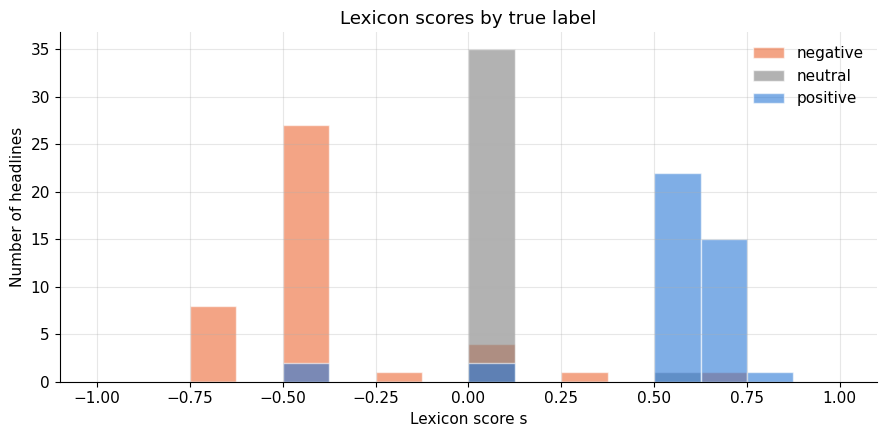

In [6]:
fig, ax = plt.subplots()
bins = np.linspace(-1, 1, 17)
for lab, c in [("negative", COLORS[1]), ("neutral", "grey"), ("positive", COLORS[0])]:
    ax.hist(news.loc[news["label"] == lab, "score"], bins=bins, alpha=0.6, color=c, label=lab, edgecolor="white")
ax.set_xlabel("Lexicon score s")
ax.set_ylabel("Number of headlines")
ax.set_title("Lexicon scores by true label")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Most neutral headlines score exactly 0, while positive and negative headlines spread out to the right and left. Few headlines score beyond ±0.7: short texts rarely contain more than two sentiment words, so the scores are coarse. In a trading application you would average scores over many headlines per company per day, which gives a smoother signal. Notebook SAR3 shows how to test whether such a signal is followed by price moves.

## 5. Takeaways and where it breaks

- **Tokenise → match a word list → score** is the simplest text-to-number pipeline, and it is fully transparent.
- **Domain matters.** Use a finance-specific lexicon (such as Loughran–McDonald) rather than a general-purpose one.
- **Negation handling is cheap and helps**, but word counting misses comparisons ("not as bad as feared"), degree ("losses narrow") and anything that needs context.
- **Neutral headlines are the hardest.** Many routine announcements contain words that look positive or negative.
- **Where it breaks:** our 120 headlines are short, clean and fictional. Real news has duplicates, typos, headlines about several companies at once, and articles where the headline and body disagree. A lexicon also can't adapt to new jargon.

**What you could build:** a lexicon-based sentiment scorer for the club, with a public word list the team can extend, plus a log of misclassified examples to guide improvements. It is the natural baseline that every fancier model (SAR5) must beat.